# Pizza Sales SQL Analytics Project

## Project Objective

The goal of this project is to analyze pizza sales data using SQL and Python to identify revenue trends, peak business hours, best-selling pizzas, category performance, and operational opportunities.

## Tools Used

- SQL
- DuckDB
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

## Key Business Questions

1. What are the monthly revenue trends?
2. Which pizzas sell the most?
3. Which pizza categories generate the highest sales?
4. What are the busiest hours by weekday?
5. What are the slowest hours?
6. How can the business improve staffing, inventory, and promotions?

## 1. Environment Setup

In [1]:
import duckdb

In [2]:
con=duckdb.connect()

## 2. Loading the Pizza Sales Dataset

In [3]:
con.execute("""
CREATE TABLE pizza_sales AS
SELECT *
FROM read_csv_auto(
    '../data/pizza_sales.csv',
    header = true,
    ignore_errors = true,
    sample_size = -1
);
""")

## 3. Previewing the Dataset

In [4]:
con.execute("SELECT * FROM pizza_sales LIMIT 5").fetchdf()


,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


## 4. Key Business Metrics

In [5]:
con.execute("""
SELECT
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(quantity) AS total_pizzas_sold,
    ROUND(SUM(total_price), 2) AS total_revenue,
    ROUND(SUM(total_price) / COUNT(DISTINCT order_id), 2) AS average_order_value,
    ROUND(SUM(quantity) * 1.0 / COUNT(DISTINCT order_id), 2) AS avg_pizzas_per_order
FROM pizza_sales;
""").fetchdf()

,total_orders,total_pizzas_sold,total_revenue,average_order_value,avg_pizzas_per_order
0,21350,49574.0,817860.05,38.31,2.32


## 5. Monthly Revenue Trend

In [6]:
con.execute("""
SELECT
    DATE_TRUNC('month',order_date) AS month,
    SUM(total_price) AS revenue
FROM pizza_sales
    GROUP BY 1
    ORDER BY month;
    """).fetchdf()

,month,revenue
0,2015-01-01,69793.30
1,2015-02-01,65159.60
2,2015-03-01,70397.10
3,2015-04-01,68736.80
4,2015-05-01,71402.75
5,2015-06-01,68230.20
6,2015-07-01,72557.90
7,2015-08-01,68278.25
8,2015-09-01,64180.05
9,2015-10-01,64027.60


## 6. Month-over-Month Revenue Growth

In [7]:
con.execute("""
WITH monthly AS (
    SELECT
        DATE_TRUNC('month',order_date) AS month,
        SUM(total_price) AS revenue
    FROM pizza_sales
    GROUP BY 1
)
SELECT 
    month,
    revenue,
    LAG(revenue)OVER(ORDER BY month) AS prev_month_revenue,
    ROUND(
    (revenue-LAG(revenue) OVER(ORDER BY month))
    /NULLIF(LAG(revenue) OVER(ORDER BY month),0)*100
    ,2) AS mom_growth_pct
FROM monthly
ORDER BY month;
""").fetchdf()

,month,revenue,prev_month_revenue,mom_growth_pct
0,2015-01-01,69793.30,NaN,NaN
1,2015-02-01,65159.60,69793.30,-6.64
2,2015-03-01,70397.10,65159.60,8.04
3,2015-04-01,68736.80,70397.10,-2.36
4,2015-05-01,71402.75,68736.80,3.88
5,2015-06-01,68230.20,71402.75,-4.44
6,2015-07-01,72557.90,68230.20,6.34
7,2015-08-01,68278.25,72557.90,-5.90
8,2015-09-01,64180.05,68278.25,-6.00
9,2015-10-01,64027.60,64180.05,-0.24


## 7. Top-Selling Pizzas by Quantity

In [8]:
con.execute("""
SELECT 
    pizza_name,
    SUM(quantity) AS total_sold
FROM pizza_sales
GROUP BY pizza_name
ORDER BY total_sold DESC
LIMIT 10
""").fetchdf()

,pizza_name,total_sold
0,The Classic Deluxe Pizza,2453.0
1,The Barbecue Chicken Pizza,2432.0
2,The Hawaiian Pizza,2422.0
3,The Pepperoni Pizza,2418.0
4,The Thai Chicken Pizza,2371.0
5,The California Chicken Pizza,2370.0
6,The Sicilian Pizza,1938.0
7,The Spicy Italian Pizza,1924.0
8,The Southwest Chicken Pizza,1917.0
9,The Big Meat Pizza,1914.0


## 8. Top Pizzas by Revenue

In [9]:
con.execute("""
SELECT 
    pizza_name,
    SUM(quantity) AS total_sold,
    ROUND(SUM(total_price), 2) AS total_revenue
FROM pizza_sales
GROUP BY pizza_name
ORDER BY total_revenue DESC
LIMIT 10;
""").fetchdf()

,pizza_name,total_sold,total_revenue
0,The Thai Chicken Pizza,2371.0,43434.25
1,The Barbecue Chicken Pizza,2432.0,42768.00
2,The California Chicken Pizza,2370.0,41409.50
3,The Classic Deluxe Pizza,2453.0,38180.50
4,The Spicy Italian Pizza,1924.0,34831.25
5,The Southwest Chicken Pizza,1917.0,34705.75
6,The Italian Supreme Pizza,1884.0,33476.75
7,The Hawaiian Pizza,2422.0,32273.25
8,The Four Cheese Pizza,1902.0,32265.70
9,The Sicilian Pizza,1938.0,30940.50


## 9. Pizza Category Performance

In [10]:
con.execute("""
SELECT 
    pizza_category,
    SUM(quantity) AS total_sold
FROM pizza_sales
GROUP BY pizza_category
ORDER BY total_sold DESC;
""").fetchdf()

,pizza_category,total_sold
0,Classic,14888.0
1,Supreme,11987.0
2,Veggie,11649.0
3,Chicken,11050.0


## 11. Daily Revenue and Day-over-Day Growth

In [11]:
con.execute("""
SELECT
    pizza_size,
    SUM(quantity) AS total_sold,
    ROUND(SUM(total_price), 2) AS revenue,
    ROUND(SUM(total_price) * 100.0 / SUM(SUM(total_price)) OVER (), 2) AS revenue_share_pct
FROM pizza_sales
GROUP BY pizza_size
ORDER BY revenue DESC;
""").fetchdf()

,pizza_size,total_sold,revenue,revenue_share_pct
0,L,18956.0,375318.70,45.89
1,M,15635.0,249382.25,30.49
2,S,14403.0,178076.50,21.77
3,XL,552.0,14076.00,1.72
4,XXL,28.0,1006.60,0.12


In [12]:
con.execute("""
WITH daily AS(
    SELECT 
        DATE_TRUNC('day',order_date) AS day,
        SUM(total_price) AS revenue
    FROM pizza_sales
    GROUP BY 1
)
SELECT
    day,
    revenue,
    LAG(revenue)OVER(ORDER BY day) AS prev_day,
    ROUND(
    (revenue-LAG(revenue) OVER(ORDER BY day))
    /NULLIF(LAG(revenue) OVER(ORDER BY day),0)*100
    ,2) AS dod_growth_pct
FROM daily
ORDER BY day;
""").fetchdf()

,day,revenue,prev_day,dod_growth_pct
0,2015-01-01,2713.85,NaN,NaN
1,2015-01-02,2731.90,2713.85,0.67
2,2015-01-03,2662.40,2731.90,-2.54
3,2015-01-04,1755.45,2662.40,-34.07
4,2015-01-05,2065.95,1755.45,17.69
...,...,...,...,...
353,2015-12-27,1419.00,1643.05,-13.64
354,2015-12-28,1637.20,1419.00,15.38
355,2015-12-29,1353.25,1637.20,-17.34
356,2015-12-30,1337.80,1353.25,-1.14


## 12. Weekday Revenue Analysis

In [13]:
con.execute("""
SELECT
    EXTRACT(DOW FROM order_date) AS weekday_num,
    strftime(order_date, '%A') AS weekday_name,
    SUM(total_price) AS revenue
FROM pizza_sales
GROUP BY weekday_num, weekday_name
ORDER BY weekday_num;
""").fetchdf()

,weekday_num,weekday_name,revenue
0,0,Sunday,99203.50
1,1,Monday,107329.55
2,2,Tuesday,114133.80
3,3,Wednesday,114408.40
4,4,Thursday,123528.50
5,5,Friday,136073.90
6,6,Saturday,123182.40


## 13. Hourly Revenue by Weekday

In [14]:
con.execute("""
SELECT 
    EXTRACT(DOW FROM order_date) AS weekday_num,
    strftime(order_date,'%A') As weekday_name,
    EXTRACT(HOUR FROM order_time) AS hour,
    SUM(total_price) AS revenue
FROM pizza_sales
GROUP BY weekday_num,weekday_name,hour
ORDER BY weekday_num,hour
""").fetchdf()

,weekday_num,weekday_name,hour,revenue
0,0,Sunday,10,37.50
1,0,Sunday,11,3818.75
2,0,Sunday,12,9988.80
3,0,Sunday,13,11452.95
4,0,Sunday,14,8466.70
...,...,...,...,...
90,6,Saturday,19,13956.25
91,6,Saturday,20,12031.60
92,6,Saturday,21,9811.15
93,6,Saturday,22,5579.30


## 14. Hourly Revenue Trend Visualization

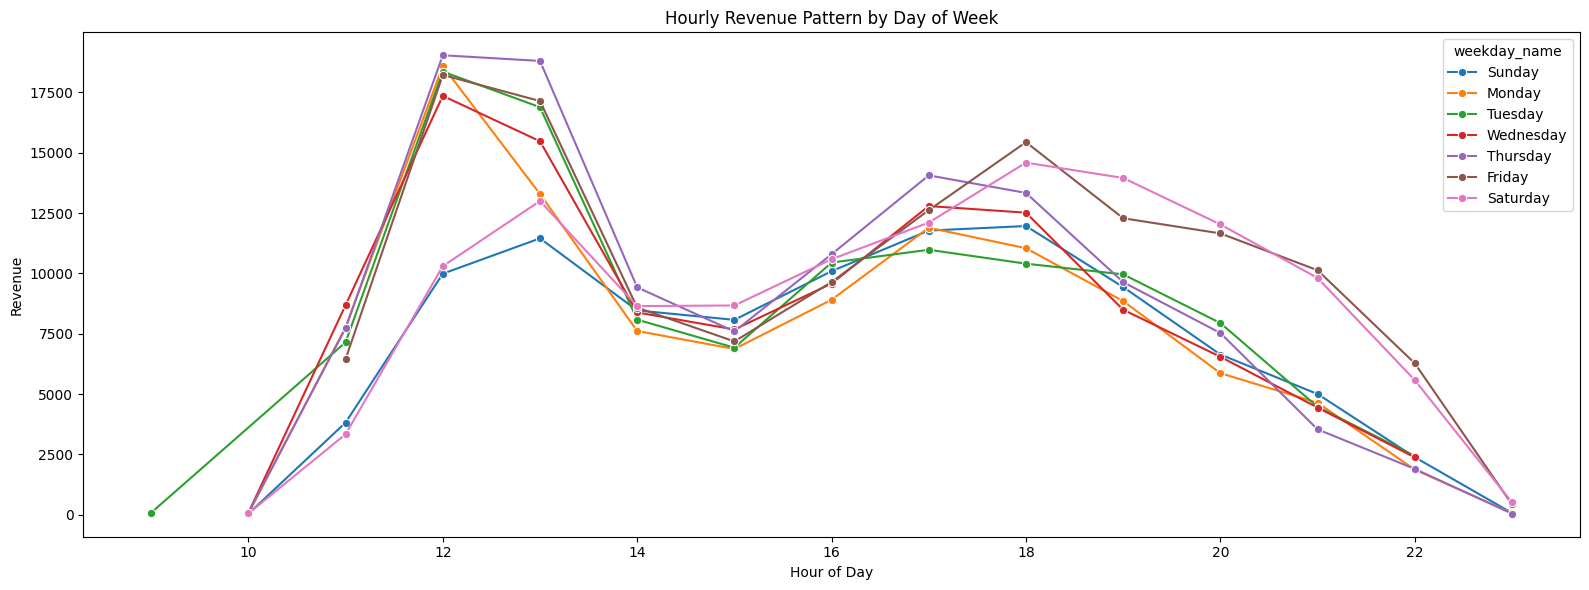

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

df = con.execute("""
SELECT
    EXTRACT(DOW FROM order_date) AS weekday_num,
    strftime(order_date, '%A') AS weekday_name,
    EXTRACT(HOUR FROM order_time) AS hour,
    SUM(total_price) AS revenue
FROM pizza_sales
GROUP BY weekday_num, weekday_name, hour
ORDER BY weekday_num, hour;
""").fetchdf()

plt.figure(figsize=(16,6))
sns.lineplot(data=df, x='hour', y='revenue', hue='weekday_name', marker='o')
plt.title("Hourly Revenue Pattern by Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")
plt.tight_layout()

In [16]:
con.execute("""
SELECT
    weekday_num,
    weekday_name,
    hour,
    CASE
        WHEN hour = 0 THEN '12AM'
        WHEN hour BETWEEN 1 AND 11 THEN hour || 'AM'
        WHEN hour = 12 THEN '12PM'
        ELSE (hour-12) || 'PM'
        END AS hour_label,
    revenue
FROM (
    SELECT 
        EXTRACT(DOW FROM order_date) AS weekday_num,
        strftime(order_date,'%A') AS weekday_name,
        EXTRACT(HOUR FROM order_time) AS hour,
        SUM(total_price) AS revenue,
        ROW_NUMBER()OVER(
            PARTITION BY EXTRACT(DOW FROM order_date)
            ORDER BY SUM(total_price) DESC
        ) AS rn
    FROM pizza_sales
    GROUP BY weekday_num,weekday_name,hour
)
WHERE rn=1
ORDER BY weekday_num;
""").fetchdf()

,weekday_num,weekday_name,hour,hour_label,revenue
0,0,Sunday,18,6PM,11964.25
1,1,Monday,12,12PM,18596.10
2,2,Tuesday,12,12PM,18364.85
3,3,Wednesday,12,12PM,17359.10
4,4,Thursday,12,12PM,19042.20
5,5,Friday,12,12PM,18227.05
6,6,Saturday,18,6PM,14591.25


## 16. Slowest Revenue Hour by Weekday

In [17]:
con.execute("""
SELECT
    weekday_num,
    weekday_name,
    hour,
    CASE
        WHEN hour = 0 THEN '12AM'
        WHEN hour BETWEEN 1 AND 11 THEN hour || 'AM'
        WHEN hour = 12 THEN '12PM'
        ELSE (hour-12) || 'PM'
        END AS hour_label,
    revenue
FROM (
    SELECT 
        EXTRACT(DOW FROM order_date) AS weekday_num,
        strftime(order_date,'%A') AS weekday_name,
        EXTRACT(HOUR FROM order_time) AS hour,
        SUM(total_price) AS revenue,
        ROW_NUMBER()OVER(
            PARTITION BY EXTRACT(DOW FROM order_date)
            ORDER BY SUM(total_price)
        ) AS rn
    FROM pizza_sales
    GROUP BY weekday_num,weekday_name,hour
)
WHERE rn=1
ORDER BY weekday_num;
""").fetchdf()

,weekday_num,weekday_name,hour,hour_label,revenue
0,0,Sunday,10,10AM,37.50
1,1,Monday,10,10AM,50.25
2,2,Tuesday,9,9AM,83.00
3,3,Wednesday,10,10AM,76.65
4,4,Thursday,23,11PM,44.00
5,5,Friday,23,11PM,430.70
6,6,Saturday,10,10AM,52.75


## 17. Weekday-Hour Revenue Pivot Table

In [18]:
con.execute("""
SELECT
    weekday_name,
    SUM(CASE WHEN hour = 0 THEN revenue END) AS h0,
    SUM(CASE WHEN hour = 1 THEN revenue END) AS h1,
    SUM(CASE WHEN hour = 2 THEN revenue END) AS h2,
    SUM(CASE WHEN hour = 3 THEN revenue END) AS h3,
    SUM(CASE WHEN hour = 4 THEN revenue END) AS h4,
    SUM(CASE WHEN hour = 5 THEN revenue END) AS h5,
    SUM(CASE WHEN hour = 6 THEN revenue END) AS h6,
    SUM(CASE WHEN hour = 7 THEN revenue END) AS h7,
    SUM(CASE WHEN hour = 8 THEN revenue END) AS h8,
    SUM(CASE WHEN hour = 9 THEN revenue END) AS h9,
    SUM(CASE WHEN hour = 10 THEN revenue END) AS h10,
    SUM(CASE WHEN hour = 11 THEN revenue END) AS h11,
    SUM(CASE WHEN hour = 12 THEN revenue END) AS h12,
    SUM(CASE WHEN hour = 13 THEN revenue END) AS h13,
    SUM(CASE WHEN hour = 14 THEN revenue END) AS h14,
    SUM(CASE WHEN hour = 15 THEN revenue END) AS h15,
    SUM(CASE WHEN hour = 16 THEN revenue END) AS h16,
    SUM(CASE WHEN hour = 17 THEN revenue END) AS h17,
    SUM(CASE WHEN hour = 18 THEN revenue END) AS h18,
    SUM(CASE WHEN hour = 19 THEN revenue END) AS h19,
    SUM(CASE WHEN hour = 20 THEN revenue END) AS h20,
    SUM(CASE WHEN hour = 21 THEN revenue END) AS h21,
    SUM(CASE WHEN hour = 22 THEN revenue END) AS h22,
    SUM(CASE WHEN hour = 23 THEN revenue END) AS h23
FROM (
    SELECT
        strftime(order_date, '%A') AS weekday_name,
        EXTRACT(HOUR FROM order_time) AS hour,
        SUM(total_price) AS revenue
    FROM pizza_sales
    GROUP BY weekday_name, hour
)
GROUP BY weekday_name
ORDER BY
    CASE weekday_name
        WHEN 'Sunday' THEN 0
        WHEN 'Monday' THEN 1
        WHEN 'Tuesday' THEN 2
        WHEN 'Wednesday' THEN 3
        WHEN 'Thursday' THEN 4
        WHEN 'Friday' THEN 5
        WHEN 'Saturday' THEN 6
    END;

""").fetchdf()

,weekday_name,h0,h1,h2,h3,h4,h5,h6,h7,h8,...,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23
0,Sunday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8466.70,8075.85,10092.25,11776.30,11964.25,9435.75,6639.10,5001.35,2384.20,69.75
1,Monday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7614.80,6868.80,8907.75,11893.70,11044.70,8853.85,5866.25,4638.15,1869.05,66.95
2,Tuesday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8084.65,6922.50,10449.70,10980.50,10403.80,9960.95,7943.85,4470.45,2433.50,NaN
3,Wednesday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8382.30,7677.25,9580.40,12792.40,12516.95,8495.45,6544.95,4439.40,2378.30,NaN
4,Thursday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9423.10,7594.30,10795.05,14064.55,13335.85,9639.60,7530.50,3537.50,1896.60,44.00
5,Friday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8583.45,7182.05,9642.15,12622.40,15440.05,12287.05,11659.15,10131.80,6274.20,430.70
6,Saturday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8646.40,8671.55,10588.10,12107.60,14591.25,13956.25,12031.60,9811.15,5579.30,509.95


## 18. Weekday-Hour Revenue Heatmap

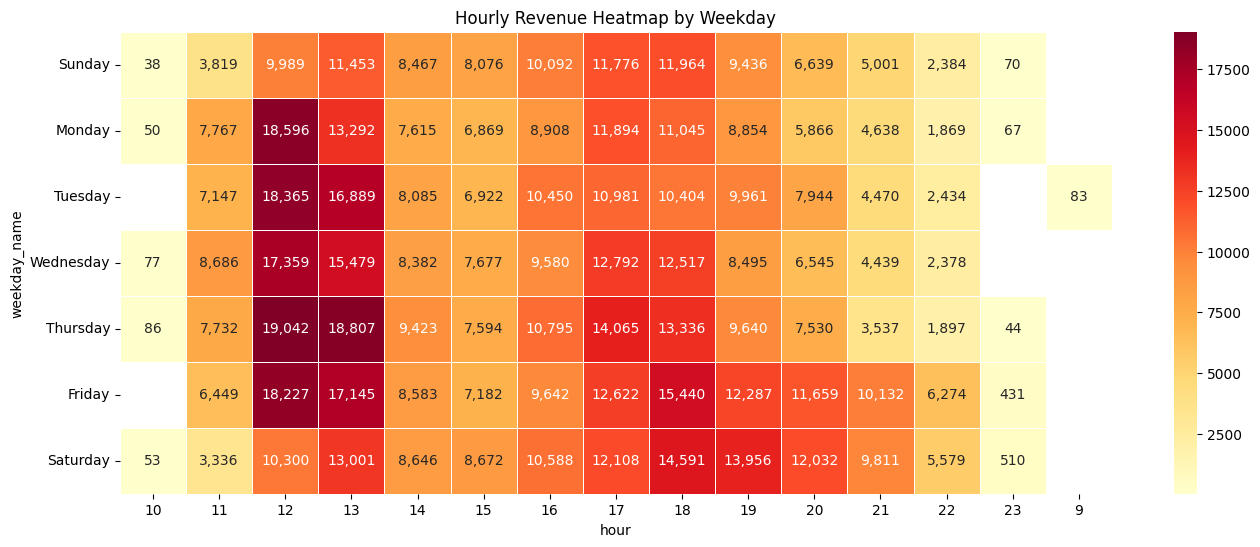

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

df = con.execute("""
SELECT
    EXTRACT(DOW FROM order_date) AS weekday_num,
    strftime(order_date, '%A') AS weekday_name,
    EXTRACT(HOUR FROM order_time) AS hour,
    SUM(total_price) AS revenue
FROM pizza_sales
GROUP BY weekday_num, weekday_name, hour
ORDER BY weekday_num, hour;
""").fetchdf()

pivot = df.pivot_table(index='weekday_name',columns='hour',values='revenue',aggfunc='sum',sort=False)

plt.figure(figsize=(16,6))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=.5, fmt=',.0f',annot=True)
plt.title("Hourly Revenue Heatmap by Weekday")
plt.show()

In [20]:
con.execute("""
SELECT
    EXTRACT(DOW FROM order_date) AS weekday_num,
    strftime(order_date, '%A') AS weekday_name,
    EXTRACT(HOUR FROM order_time) AS hour,
    SUM(total_price) AS revenue
FROM pizza_sales
GROUP BY weekday_num, weekday_name, hour
ORDER BY weekday_num, hour;
""").fetchdf()

,weekday_num,weekday_name,hour,revenue
0,0,Sunday,10,37.50
1,0,Sunday,11,3818.75
2,0,Sunday,12,9988.80
3,0,Sunday,13,11452.95
4,0,Sunday,14,8466.70
...,...,...,...,...
90,6,Saturday,19,13956.25
91,6,Saturday,20,12031.60
92,6,Saturday,21,9811.15
93,6,Saturday,22,5579.30


## 19. Insights and Recommendations

### 1. Weekday Lunch and Weekend Dinner Show Different Demand Patterns

The hourly revenue analysis and heatmap show two clear demand patterns. Weekdays generate stronger revenue during lunch hours, especially between 11 AM and 2 PM. On weekends, revenue shifts more toward the evening period, especially around 6 PM to 8 PM.

This may suggest that weekday demand is linked to quick lunch purchases, while weekend demand may be connected to leisure-time or group ordering. However, customer-level data would be needed to confirm the exact customer behaviour.

**Recommendation:**  
Increase staffing and food preparation during weekday lunch hours and weekend dinner hours. These periods should receive more operational focus because they consistently generate stronger revenue.

---

### 2. Morning and Late-Night Hours Generate Lower Revenue

The slowest-hour analysis shows that morning and late-night periods are consistently low-revenue windows. These periods appear lighter in the heatmap and contribute less to total sales compared with lunch and dinner hours.

**Recommendation:**  
Avoid scheduling full staff during low-demand hours. These quieter periods can be used for preparation, cleaning, stock checking, and other operational tasks. The business could also test small promotions during slow periods if it wants to increase demand.

---

### 3. Thursday Lunch Is a Strong Revenue Opportunity

Thursday at 12 PM appears as one of the strongest revenue periods in the dataset. This suggests that Thursday lunch is a valuable time slot that the business can use more strategically.

**Recommendation:**  
Prepare additional inventory before Thursday lunch and ensure enough staff are available. The business could also test a Thursday lunch promotion to increase sales further during an already strong period.

---

### 4. Weekend Evening Demand Can Be Used for Higher-Value Offers

Saturday and Sunday evenings show strong revenue performance, especially around dinner time. This makes weekend evenings a good opportunity for promoting larger orders and higher-value menu combinations.

**Recommendation:**  
Promote family bundles, large-size pizzas, sides, and drink combinations during weekend evenings. Extra kitchen and delivery support may also help reduce waiting time during these busy periods.

---

### 5. Inventory Planning Should Follow Hourly Demand Patterns

The analysis shows clear differences between high-demand and low-demand periods. Weekday lunch and weekend dinner require more preparation, while mornings and late nights require less.

**Recommendation:**  
Prepare more dough, toppings, and sides before peak periods. Reduce preparation during slow periods to avoid waste and maintain freshness.

---

### 6. Pizza Performance Can Support Menu and Promotion Decisions

The project identifies both top-selling pizzas by quantity and top pizzas by revenue. This is useful because the most frequently sold pizzas are not always the highest revenue contributors.

**Recommendation:**  
Use quantity-based results for inventory planning and revenue-based results for promotion planning. High-revenue pizzas can be promoted in bundles, while high-volume pizzas should be prioritized for ingredient availability.

---

### 7. Data-Driven Scheduling Can Improve Efficiency

The heatmap clearly shows when the business is busiest and quietest across the week. This makes it useful for planning staff schedules more efficiently.

**Recommendation:**  
Create a dynamic staffing schedule based on hourly revenue patterns. More staff should be assigned during high-revenue windows, while fewer staff are needed during consistently slow periods.

## 20. Project Summary

This project analyzed pizza sales data using SQL, DuckDB, Python, and data visualization techniques. The main goal was to understand revenue trends, product performance, peak sales periods, slow hours, and operational opportunities for a pizza business.

The analysis began with key business metrics such as total orders, total pizzas sold, total revenue, average order value, and average pizzas per order. After that, SQL queries were used to study monthly revenue trends, month-over-month growth, daily revenue changes, top-selling pizzas, pizza category performance, pizza size contribution, weekday revenue, hourly revenue, peak hours, and slowest hours.

The results show that sales are strongly influenced by time of day and day of week. Weekday lunch hours, especially between 11 AM and 2 PM, show strong revenue performance. Weekend evenings, especially around 6 PM to 8 PM, also show high demand. In contrast, morning and late-night periods generate lower revenue across most days.

The product-level analysis shows which pizzas perform best by quantity sold and which pizzas contribute the most revenue. This distinction is important because high-volume products are useful for inventory planning, while high-revenue products are useful for promotion and pricing decisions.

Overall, this project shows how SQL can be used to turn transaction-level sales data into practical business insights. The findings can support better staffing decisions, inventory planning, promotion timing, and menu strategy.